Source Image:


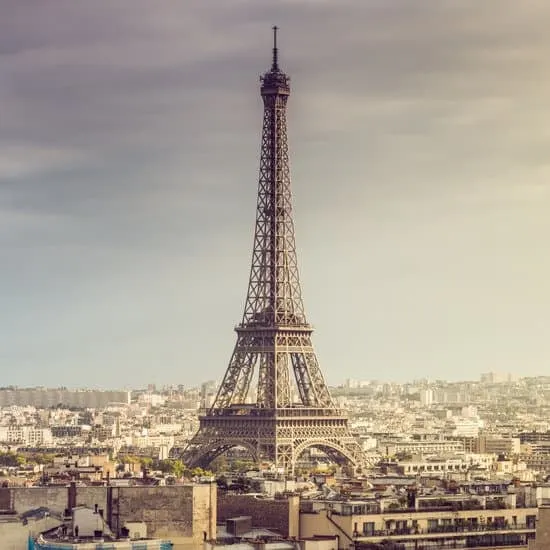

Target Image:


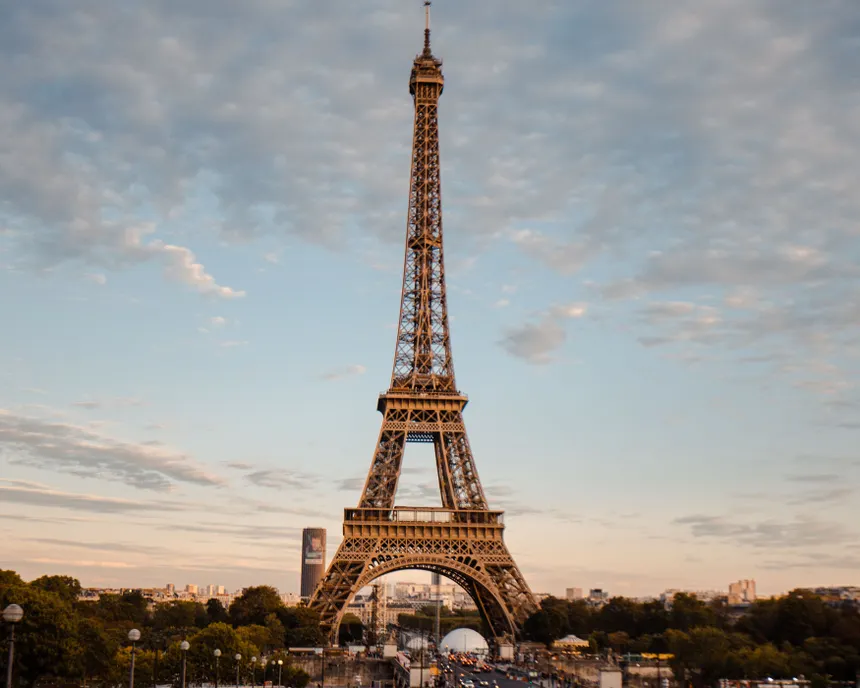

Resulting Matched (Merged) Image:


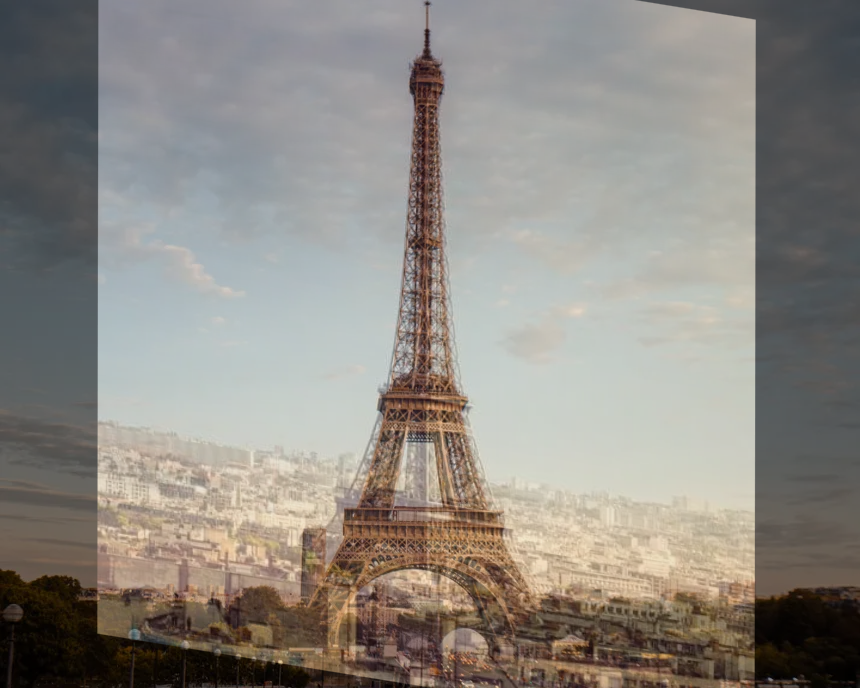

In [13]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# ------------------ Affine ------------------

def estimate_affine(s, t):
    num = s.shape[1]
    M = np.zeros((2 * num, 6))
    for i in range(num):
        temp = [
            [s[0, i], s[1, i], 0, 0, 1, 0],
            [0, 0, s[0, i], s[1, i], 0, 1]
        ]
        M[2 * i:2 * i + 2, :] = np.array(temp)
    b = t.T.reshape((2 * num, 1))
    theta = np.linalg.lstsq(M, b, rcond=None)[0]
    X = theta[:4].reshape((2, 2))
    Y = theta[4:]
    return X, Y

# ------------------ RANSAC ------------------

K = 3
threshold = 1
ITER_NUM = 2000

def residual_lengths(X, Y, s, t):
    e = np.dot(X, s) + Y
    diff_square = np.power(e - t, 2)
    residual = np.sqrt(np.sum(diff_square, axis=0))
    return residual

def ransac_fit(pts_s, pts_t):
    inliers_num = 0
    A = None
    t = None
    inliers = None
    for i in range(ITER_NUM):
        idx = np.random.choice(pts_s.shape[1], K, replace=False)
        A_tmp, t_tmp = estimate_affine(pts_s[:, idx], pts_t[:, idx])
        residual = residual_lengths(A_tmp, t_tmp, pts_s, pts_t)
        inliers_tmp = np.where(residual < threshold)
        inliers_num_tmp = len(inliers_tmp[0])
        if inliers_num_tmp > inliers_num:
            inliers_num = inliers_num_tmp
            inliers = inliers_tmp
            A = A_tmp
            t = t_tmp
    return A, t, inliers

# ------------------ SIFT ------------------

def extract_SIFT(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kp, desc = sift.detectAndCompute(gray, None)
    kp = np.array([p.pt for p in kp]).T
    return kp, desc

def match_SIFT(desc1, desc2):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)
    pos = np.array([], dtype=np.int32).reshape((0, 2))
    for i in range(len(matches)):
        if matches[i][0].distance <= 0.8 * matches[i][1].distance:
            temp = np.array([matches[i][0].queryIdx, matches[i][0].trainIdx])
            pos = np.vstack((pos, temp))
    return pos

def affine_matrix(s, t, pos):
    s = s[:, pos[:, 0]]
    t = t[:, pos[:, 1]]
    _, _, inliers = ransac_fit(s, t)
    s = s[:, inliers[0]]
    t = t[:, inliers[0]]
    A, T = estimate_affine(s, t)
    M = np.hstack((A, T))
    return M

# ------------------ MAIN ------------------

img_source = cv2.imread("/media/femboy.jpg")
img_target = cv2.imread("/media/femboy2.jpg")

if img_source is not None and img_target is not None:
    print("Source Image:")
    cv2_imshow(img_source)

    print("Target Image:")
    cv2_imshow(img_target)

    kp_source, des_source = extract_SIFT(img_source)
    kp_target, des_target = extract_SIFT(img_target)
    pos = match_SIFT(des_source, des_target)
    H = affine_matrix(kp_source, kp_target, pos)

    rows, cols, _ = img_target.shape
    warp = cv2.warpAffine(img_source, H, (cols, rows))
    merge = np.uint8(img_target * 0.5 + warp * 0.5)

    print("Resulting Matched (Merged) Image:")
    cv2_imshow(merge)
else:
    if img_source is None: print("Cannot load /media/femboy.jpg")
    if img_target is None: print("Cannot load /media/femboy2.jpg")

In [7]:
import os

media_path = '/media/'
if os.path.exists(media_path):
    print(f"Files in {media_path}:")
    display(os.listdir(media_path))
else:
    print(f"Directory {media_path} does not exist.")

Files in /media/:


['femboy.jpg', 'femboy2.jpg']

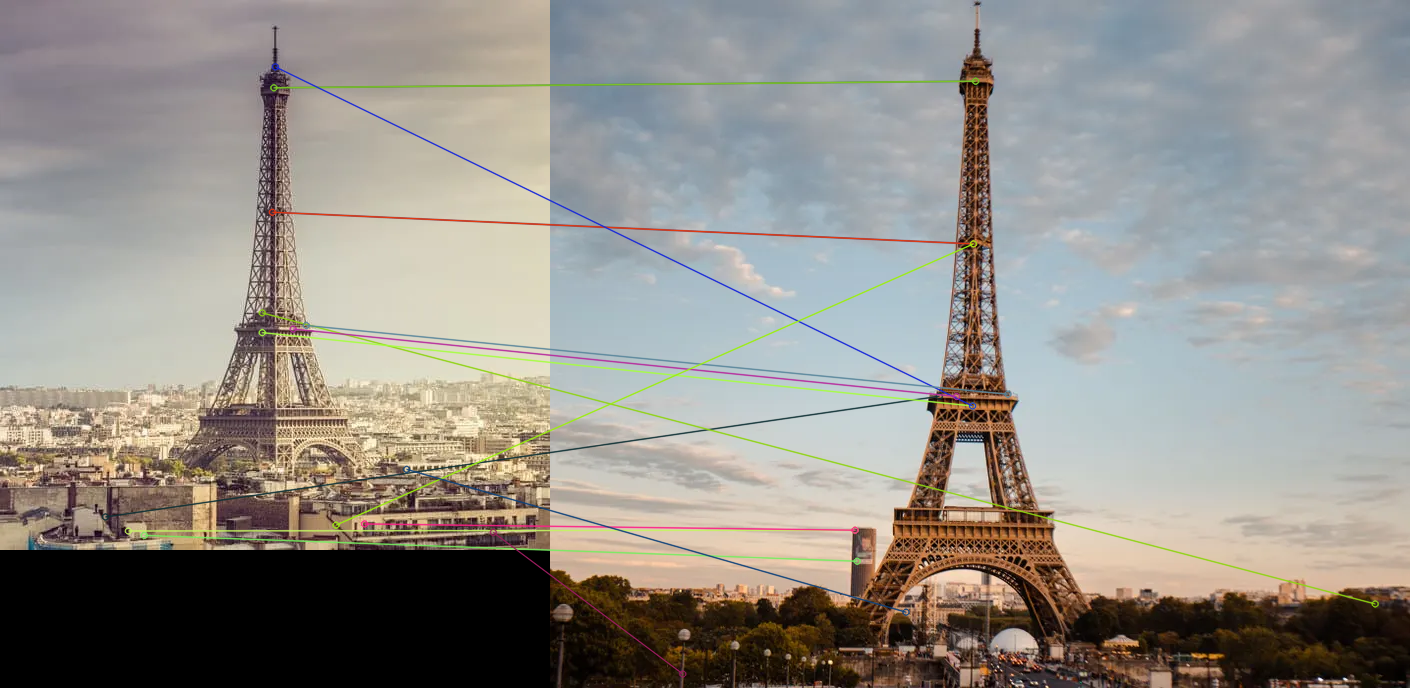

In [19]:
import cv2
from google.colab.patches import cv2_imshow

img1 = cv2.imread("/media/femboy.jpg")
img2 = cv2.imread("/media/femboy2.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append([m])

result = cv2.drawMatchesKnn(
    img1,
    kp1,
    img2,
    kp2,
    good[:100],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

cv2_imshow(result)